# LSTM - NLP Log Anomaly Detection



## Step 1 - Install and Import Libraries

In [24]:
# Install required packages
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Scikit-learn metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, precision_score, recall_score,
    roc_curve, precision_recall_curve, average_precision_score
)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Pandas version     : {pd.__version__}")
print("All libraries loaded successfully.")

TensorFlow version : 2.19.0
GPU available      : True
Pandas version     : 2.2.2
All libraries loaded successfully.


## Step 2 - Load Dataset

In [25]:
# Upload full_dataset_final.csv first if not already done
# from google.colab import files
# files.upload()

df = pd.read_csv('full_dataset_final.csv')
df['cleaned_log'] = df['cleaned_log'].fillna('')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Total logs     : {len(df):,}")
print(f"  Normal  (0)    : {(df['label']==0).sum():,}  ({(df['label']==0).mean()*100:.1f}%)")
print(f"  Anomaly (1)    : {(df['label']==1).sum():,}  ({(df['label']==1).mean()*100:.1f}%)")
print(f"  Columns        : {df.columns.tolist()}")
print()
print("Log sources:")
print(df['source'].value_counts().to_string())
print()
print("Sample logs:")
df[['cleaned_log','label','source']].head(8)

  DATASET OVERVIEW
  Total logs     : 7,254
  Normal  (0)    : 4,687  (64.6%)
  Anomaly (1)    : 2,567  (35.4%)
  Columns        : ['cleaned_log', 'label', 'source']

Log sources:
source
HDFS            2000
OpenSSH         2000
Linux           2000
cloud_syslog    1129
cloud_auth       125

Sample logs:


,cleaned_log,label,source
0,packetresponder for block block_id terminating,0,HDFS
1,packetresponder for block block_id terminating,0,HDFS
2,block hostname blockmap updated ip_addr num is...,0,HDFS
3,packetresponder for block block_id terminating,0,HDFS
4,packetresponder for block block_id terminating,0,HDFS
5,block hostname blockmap updated ip_addr num is...,0,HDFS
6,block hostname blockmap updated ip_addr num is...,0,HDFS
7,block hostname blockmap updated ip_addr num is...,0,HDFS


## Step 3 - Text Tokenisation and Sequence Preparation

In [26]:
# ── Parameters ──────────────────────────────────────
VOCAB_SIZE   = 2500    # vocabulary size (unique words in dataset ≈ 2,016)
MAX_LEN      = 20      # max words per log (99th percentile = 18 words)
EMBED_DIM    = 64      # embedding dimensions
LSTM_UNITS   = 128     # LSTM hidden units
DROPOUT      = 0.3     # dropout rate
BATCH_SIZE   = 64
EPOCHS       = 20
LR           = 0.001

print("LSTM Configuration:")
print(f"  Vocabulary size  : {VOCAB_SIZE}")
print(f"  Max sequence len : {MAX_LEN}")
print(f"  Embedding dim    : {EMBED_DIM}")
print(f"  LSTM units       : {LSTM_UNITS}")
print(f"  Dropout          : {DROPOUT}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Max epochs       : {EPOCHS}")
print()

# ── Tokenise ─────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_log'])

sequences = tokenizer.texts_to_sequences(df['cleaned_log'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

print(f"Tokenised. Actual vocabulary size: {len(tokenizer.word_index):,}")
print(f"Padded sequence shape: {X.shape}")
print()
print("Example - original log:")
print(f"  '{df['cleaned_log'].iloc[0]}'")
print("Tokenised sequence:")
print(f"  {sequences[0]}")
print("Padded:")
print(f"  {X[0]}")

LSTM Configuration:
  Vocabulary size  : 2500
  Max sequence len : 20
  Embedding dim    : 64
  LSTM units       : 128
  Dropout          : 0.3
  Batch size       : 64
  Max epochs       : 20

Tokenised. Actual vocabulary size: 1,956
Padded sequence shape: (7254, 20)

Example - original log:
  'packetresponder for block block_id terminating'
Tokenised sequence:
  [46, 10, 4, 4, 6, 47]
Padded:
  [46 10  4  4  6 47  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


## Step 4 - Train / Validation / Test Split

In [27]:
# 70% train, 15% validation, 15% test - stratified to keep anomaly ratio
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)
# 0.176 of 0.85 ≈ 0.15 of total

print(f"Training set   : {X_train.shape[0]:,} logs  ({y_train.mean()*100:.1f}% anomaly)")
print(f"Validation set : {X_val.shape[0]:,} logs  ({y_val.mean()*100:.1f}% anomaly)")
print(f"Test set       : {X_test.shape[0]:,} logs  ({y_test.mean()*100:.1f}% anomaly)")
print()

# Class weights to handle imbalance (normal:anomaly = 1.83:1)
n_normal  = (y_train == 0).sum()
n_anomaly = (y_train == 1).sum()
weight_normal  = 1.0
weight_anomaly = n_normal / n_anomaly
class_weight = {0: weight_normal, 1: weight_anomaly}
print(f"Class weights - Normal: {weight_normal:.2f}  |  Anomaly: {weight_anomaly:.2f}")
print("(Higher weight on anomaly prevents the model from ignoring minority class)")

Training set   : 5,079 logs  (35.4% anomaly)
Validation set : 1,086 logs  (35.4% anomaly)
Test set       : 1,089 logs  (35.4% anomaly)

Class weights - Normal: 1.00  |  Anomaly: 1.82
(Higher weight on anomaly prevents the model from ignoring minority class)


## Step 5 - Build the LSTM Model

In [28]:
# ── Architecture ──────────────────────────────────────
# Embedding → BiLSTM → Dropout → Dense → Output
#
# Embedding : maps each word index to a 64-dim vector
# BiLSTM    : reads log text forwards AND backwards
#             captures context from both directions
# Dropout   : prevents overfitting
# Dense 64  : fully connected layer with ReLU
# Dense 1   : sigmoid output → probability of anomaly

model = Sequential([
    # Word embedding layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        name='embedding'
    ),

    # Bidirectional LSTM - reads sequence both ways
    Bidirectional(
        LSTM(LSTM_UNITS, return_sequences=False, name='lstm'),
        name='bidirectional_lstm'
    ),

    # Regularisation
    Dropout(DROPOUT, name='dropout_1'),

    # Dense classification layers
    Dense(64, activation='relu', name='dense_1'),
    Dropout(0.2, name='dropout_2'),
    Dense(1, activation='sigmoid', name='output')
])

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

model.summary()
print()

# Build the model explicitly before counting params
model.build(input_shape=(None, MAX_LEN))
print(f"Total parameters: {model.count_params():,}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Total parameters: 374,145


## Step 6 - Train the LSTM Model

In [29]:
# ── Callbacks ─────────────────────────────────────────
# EarlyStopping  : stops training if val_loss stops improving (saves time)
# ReduceLROnPlateau : reduces learning rate when stuck

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Training LSTM model...")
print(f"Batch size: {BATCH_SIZE}  |  Max epochs: {EPOCHS}")
print("-" * 55)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print()
print(f"Training stopped at epoch: {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

Training LSTM model...
Batch size: 64  |  Max epochs: 20
-------------------------------------------------------
Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9238 - auc: 0.9808 - loss: 0.2475 - precision: 0.9368 - recall: 0.8415 - val_accuracy: 0.9991 - val_auc: 1.0000 - val_loss: 0.0079 - val_precision: 1.0000 - val_recall: 0.9974 - learning_rate: 0.0010
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9990 - auc: 0.9992 - loss: 0.0103 - precision: 0.9983 - recall: 0.9989 - val_accuracy: 0.9982 - val_auc: 1.0000 - val_loss: 0.0137 - val_precision: 0.9948 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9992 - auc: 1.0000 - loss: 0.0034 - precision: 0.9983 - recall: 0.9994 - val_accuracy: 0.9991 - val_auc: 1.0000 - val_loss: 0.0051 - val_precision: 1.0000 - val_recall: 0.9974 - learning_rate: 0.0010
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9992 - auc: 0.9997 - loss: 

## Step 7 - Evaluate on Test Set

In [30]:
# Generate predictions on test set
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Generate anomaly scores for FULL dataset
y_prob_all = model.predict(X, verbose=0).flatten()
y_pred_all = (y_prob_all >= 0.5).astype(int)

# ── Metrics ───────────────────────────────────────────
f1      = f1_score(y_test, y_pred)
f1_0    = f1_score(y_test, y_pred, pos_label=0)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
ap      = average_precision_score(y_test, y_prob)
cm      = confusion_matrix(y_test, y_pred)
fpr_val = cm[0,1] / (cm[0,0] + cm[0,1]) if (cm[0,0]+cm[0,1]) > 0 else 0

print("=" * 55)
print("  LSTM PERFORMANCE (Test Set)")
print("=" * 55)
print(f"  F1-Score  (Anomaly) : {f1:.4f}")
print(f"  F1-Score  (Normal)  : {f1_0:.4f}")
print(f"  Precision           : {prec:.4f}")
print(f"  Recall              : {rec:.4f}")
print(f"  ROC-AUC             : {roc_auc:.4f}")
print(f"  Average Precision   : {ap:.4f}")
print(f"  False Positive Rate : {fpr_val:.4f}")
print()
print("Confusion Matrix:")
print(f"  True Normal  predicted Normal  : {cm[0,0]:,}")
print(f"  True Normal  predicted Anomaly : {cm[0,1]:,}")
print(f"  True Anomaly predicted Normal  : {cm[1,0]:,}")
print(f"  True Anomaly predicted Anomaly : {cm[1,1]:,}")
print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Anomaly']))

# Save metrics
metrics = {
    'model': 'LSTM (Bidirectional)',
    'f1_anomaly': round(float(f1), 4),
    'f1_normal':  round(float(f1_0), 4),
    'precision':  round(float(prec), 4),
    'recall':     round(float(rec), 4),
    'roc_auc':    round(float(roc_auc), 4),
    'avg_precision': round(float(ap), 4),
    'fpr':        round(float(fpr_val), 4),
    'epochs_trained': len(history.history['loss']),
    'vocab_size': VOCAB_SIZE,
    'max_len': MAX_LEN,
    'embed_dim': EMBED_DIM,
    'lstm_units': LSTM_UNITS,
}
with open('lstm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved to lstm_metrics.json")

  LSTM PERFORMANCE (Test Set)
  F1-Score  (Anomaly) : 0.9987
  F1-Score  (Normal)  : 0.9993
  Precision           : 0.9974
  Recall              : 1.0000
  ROC-AUC             : 0.9996
  Average Precision   : 0.9991
  False Positive Rate : 0.0014

Confusion Matrix:
  True Normal  predicted Normal  : 703
  True Normal  predicted Anomaly : 1
  True Anomaly predicted Normal  : 0
  True Anomaly predicted Anomaly : 385

Full Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       704
     Anomaly       1.00      1.00      1.00       385

    accuracy                           1.00      1089
   macro avg       1.00      1.00      1.00      1089
weighted avg       1.00      1.00      1.00      1089

Metrics saved to lstm_metrics.json


## Step 8 - Add Anomaly Scores to Full Dataset

In [31]:
# Add LSTM anomaly scores to the original dataframe
df['lstm_anomaly_score']     = y_prob_all
df['lstm_anomaly_score_pct'] = (y_prob_all * 100).round(1)
df['lstm_prediction']        = y_pred_all

# Severity classification based on score
def get_severity(score):
    if score >= 0.90: return 'CRITICAL'
    if score >= 0.70: return 'HIGH'
    if score >= 0.50: return 'MEDIUM'
    if score >= 0.30: return 'LOW'
    return 'NORMAL'

df['severity'] = df['lstm_anomaly_score'].apply(get_severity)

print("Anomaly score statistics:")
print(df['lstm_anomaly_score'].describe().round(4))
print()
print("Severity breakdown:")
print(df['severity'].value_counts())
print()
print("Top 10 highest anomaly scores:")
top10 = df.nlargest(10, 'lstm_anomaly_score')[['cleaned_log','source','label','lstm_anomaly_score_pct','severity']]
print(top10.to_string())

# Save results
df.to_csv('lstm_results_full.csv', index=False)
print()
print("Full results saved to lstm_results_full.csv")

Anomaly score statistics:
count    7254.0000
mean        0.3539
std         0.4781
min         0.0000
25%         0.0000
50%         0.0001
75%         1.0000
max         1.0000
Name: lstm_anomaly_score, dtype: float64

Severity breakdown:
severity
NORMAL      4687
CRITICAL    2567
Name: count, dtype: int64

Top 10 highest anomaly scores:
                                                                                          cleaned_log   source  label  lstm_anomaly_score_pct  severity
2003  authentication failure logname uid euid tty nodevssh ruser rhost hostnamehostname net user root  OpenSSH      1                   100.0  CRITICAL
2004  authentication failure logname uid euid tty nodevssh ruser rhost hostnamehostname net user root  OpenSSH      1                   100.0  CRITICAL
2005  authentication failure logname uid euid tty nodevssh ruser rhost hostnamehostname net user root  OpenSSH      1                   100.0  CRITICAL
2006  authentication failure logname uid euid tty n

## Step 9 - Visualisations

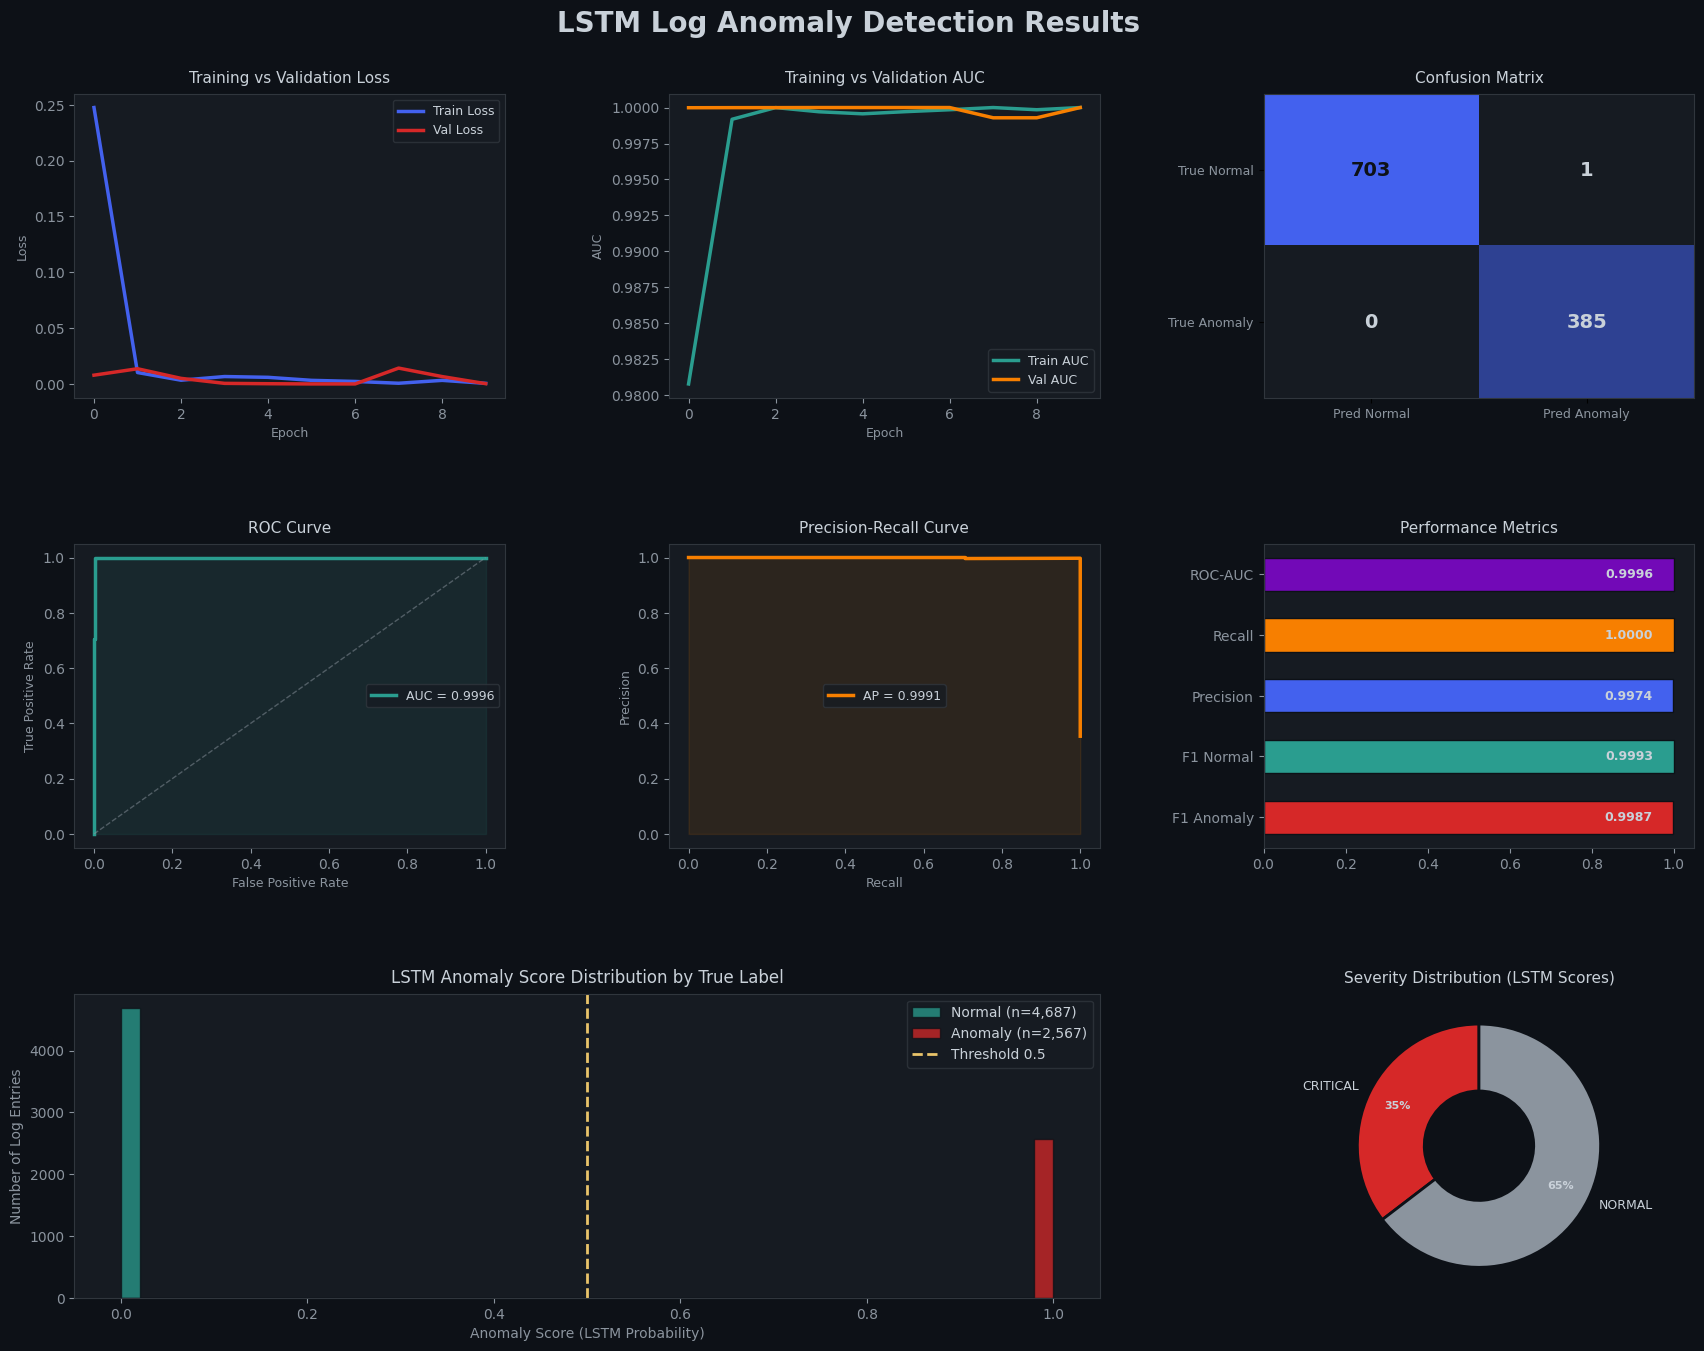

Charts saved to lstm_performance_charts.png


In [34]:
DARK   = '#0d1117'; CARD='#161b22'; BORDER='#30363d'
BLUE   = '#4361ee'; GREEN='#2a9d8f'; RED='#d62828'
ORANGE = '#f77f00'; YELLOW='#e9c46a'; WHITE='#c9d1d9'; GREY='#8b949e'
ACCENT = '#7209b7'

fig = plt.figure(figsize=(18, 14), facecolor=DARK)
fig.suptitle('LSTM Log Anomaly Detection Results',
             fontsize=20, fontweight='bold', color=WHITE, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38,
                       top=0.92, bottom=0.06, left=0.07, right=0.97)

# A: Training Loss
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor(CARD)
ax_a.plot(history.history['loss'],     color=BLUE,  lw=2.5, label='Train Loss')
ax_a.plot(history.history['val_loss'], color=RED,   lw=2.5, label='Val Loss')
ax_a.set_title('Training vs Validation Loss', color=WHITE, fontsize=11, pad=8)
ax_a.set_xlabel('Epoch', color=GREY, fontsize=9)
ax_a.set_ylabel('Loss', color=GREY, fontsize=9)
ax_a.tick_params(colors=GREY)
[sp.set_edgecolor(BORDER) for sp in ax_a.spines.values()]
ax_a.legend(fontsize=9, facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE)

# B: Training AUC
ax_b = fig.add_subplot(gs[0, 1])
ax_b.set_facecolor(CARD)
ax_b.plot(history.history['auc'],     color=GREEN,  lw=2.5, label='Train AUC')
ax_b.plot(history.history['val_auc'], color=ORANGE, lw=2.5, label='Val AUC')
ax_b.set_title('Training vs Validation AUC', color=WHITE, fontsize=11, pad=8)
ax_b.set_xlabel('Epoch', color=GREY, fontsize=9)
ax_b.set_ylabel('AUC', color=GREY, fontsize=9)
ax_b.tick_params(colors=GREY)
[sp.set_edgecolor(BORDER) for sp in ax_b.spines.values()]
ax_b.legend(fontsize=9, facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE)

# C: Confusion Matrix
ax_c = fig.add_subplot(gs[0, 2])
ax_c.set_facecolor(CARD)
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('c', [CARD, BLUE], N=256)
ax_c.imshow(cm, cmap=cmap, aspect='auto')
for i in range(2):
    for j in range(2):
        col = WHITE if cm[i,j] < cm.max()*0.6 else DARK
        ax_c.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                  fontsize=14, fontweight='bold', color=col)
ax_c.set_xticks([0,1]); ax_c.set_yticks([0,1])
ax_c.set_xticklabels(['Pred Normal','Pred Anomaly'], color=GREY, fontsize=9)
ax_c.set_yticklabels(['True Normal','True Anomaly'], color=GREY, fontsize=9)
ax_c.set_title('Confusion Matrix', color=WHITE, fontsize=11, pad=8)
[sp.set_edgecolor(BORDER) for sp in ax_c.spines.values()]

# D: ROC Curve
ax_d = fig.add_subplot(gs[1, 0])
ax_d.set_facecolor(CARD)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob)
ax_d.plot(fpr_c, tpr_c, color=GREEN, lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax_d.plot([0,1],[0,1], color=GREY, lw=1, linestyle='--', alpha=0.5)
ax_d.fill_between(fpr_c, tpr_c, alpha=0.1, color=GREEN)
ax_d.set_title('ROC Curve', color=WHITE, fontsize=11, pad=8)
ax_d.set_xlabel('False Positive Rate', color=GREY, fontsize=9)
ax_d.set_ylabel('True Positive Rate', color=GREY, fontsize=9)
ax_d.tick_params(colors=GREY)
[sp.set_edgecolor(BORDER) for sp in ax_d.spines.values()]
ax_d.legend(fontsize=9, facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE)

# E: Precision-Recall Curve
ax_e = fig.add_subplot(gs[1, 1])
ax_e.set_facecolor(CARD)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
ax_e.plot(rec_c, prec_c, color=ORANGE, lw=2.5, label=f'AP = {ap:.4f}')
ax_e.fill_between(rec_c, prec_c, alpha=0.1, color=ORANGE)
ax_e.set_title('Precision-Recall Curve', color=WHITE, fontsize=11, pad=8)
ax_e.set_xlabel('Recall', color=GREY, fontsize=9)
ax_e.set_ylabel('Precision', color=GREY, fontsize=9)
ax_e.tick_params(colors=GREY)
[sp.set_edgecolor(BORDER) for sp in ax_e.spines.values()]
ax_e.legend(fontsize=9, facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE)

# F: Metrics bar
ax_f = fig.add_subplot(gs[1, 2])
ax_f.set_facecolor(CARD)
f1_names = ['F1 Anomaly','F1 Normal','Precision','Recall','ROC-AUC']
f1_vals  = [f1, f1_0, prec, rec, roc_auc]
f1_cols  = [RED, GREEN, BLUE, ORANGE, ACCENT]
bars = ax_f.barh(f1_names, f1_vals, color=f1_cols, edgecolor=DARK, height=0.55)
for bar, val in zip(bars, f1_vals):
    ax_f.text(max(bar.get_width()-0.05, 0.01),
              bar.get_y()+bar.get_height()/2,
              f'{val:.4f}', va='center',
              ha='right' if val>0.3 else 'left',
              color=WHITE, fontsize=9, fontweight='bold')
ax_f.set_xlim(0, 1.05)
ax_f.set_title('Performance Metrics', color=WHITE, fontsize=11, pad=8)
ax_f.tick_params(colors=GREY)
[sp.set_edgecolor(BORDER) for sp in ax_f.spines.values()]

# G: Anomaly score distribution
ax_g = fig.add_subplot(gs[2, 0:2])
ax_g.set_facecolor(CARD)
bins = np.linspace(0, 1, 50)
ax_g.hist(df[df['label']==0]['lstm_anomaly_score'], bins=bins,
          alpha=0.75, color=GREEN,
          label=f"Normal (n={(df['label']==0).sum():,})", edgecolor=DARK)
ax_g.hist(df[df['label']==1]['lstm_anomaly_score'], bins=bins,
          alpha=0.75, color=RED,
          label=f"Anomaly (n={(df['label']==1).sum():,})", edgecolor=DARK)
ax_g.axvline(0.5, color=YELLOW, linestyle='--', lw=2, label='Threshold 0.5')
ax_g.set_title('LSTM Anomaly Score Distribution by True Label',
               color=WHITE, fontsize=12, pad=8)
ax_g.set_xlabel('Anomaly Score (LSTM Probability)', color=GREY, fontsize=10)
ax_g.set_ylabel('Number of Log Entries', color=GREY, fontsize=10)
ax_g.tick_params(colors=GREY)
[sp.set_edgecolor(BORDER) for sp in ax_g.spines.values()]
ax_g.legend(fontsize=10, facecolor=CARD, edgecolor=BORDER, labelcolor=WHITE)

# H: Severity pie
ax_h = fig.add_subplot(gs[2, 2])
ax_h.set_facecolor(CARD)
sev_order  = ['CRITICAL','HIGH','MEDIUM','LOW','NORMAL']
sev_colors = [RED, ORANGE, YELLOW, GREEN, GREY]
sev_counts = [df[df['severity']==s].shape[0] for s in sev_order]
sev_nonzero = [(s,c,col) for s,c,col in zip(sev_order,sev_counts,sev_colors) if c > 0]
if sev_nonzero:
    labels, counts, colors = zip(*sev_nonzero)
    wedges, texts, autotexts = ax_h.pie(
        counts, labels=labels, colors=colors,
        autopct='%1.0f%%', startangle=90, pctdistance=0.75,
        wedgeprops=dict(width=0.55, edgecolor=DARK, linewidth=2)
    )
    for t in texts:    t.set_color(WHITE); t.set_fontsize(9)
    for a in autotexts: a.set_color(WHITE); a.set_fontsize(8); a.set_fontweight('bold')
ax_h.set_title('Severity Distribution (LSTM Scores)', color=WHITE, fontsize=11, pad=8)

plt.savefig('lstm_performance_charts.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
plt.show()
print('Charts saved to lstm_performance_charts.png')

## Step 10 - Save Model and Download Results

In [33]:
import os, pickle

os.makedirs('lstm_model', exist_ok=True)

# Save Keras model
model.save('lstm_model/lstm_anomaly_detector.h5')

# Save tokenizer
with open('lstm_model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save config
config = {
    'vocab_size': VOCAB_SIZE,
    'max_len':    MAX_LEN,
    'embed_dim':  EMBED_DIM,
    'lstm_units': LSTM_UNITS,
    'threshold':  0.5
}
with open('lstm_model/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Files saved:")
print("  lstm_model/lstm_anomaly_detector.h5  - Keras model")
print("  lstm_model/tokenizer.pkl             - Tokenizer")
print("  lstm_model/config.json               - Model config")
print("  lstm_results_full.csv                - All 7,254 logs with scores")
print("  lstm_metrics.json                    - Performance metrics")
print("  lstm_performance_charts.png          - All visualisation charts")
print("  model_comparison.csv                 - RF vs LSTM comparison")
print()

# Download all files from Colab
try:
    from google.colab import files
    for fname in [
        'lstm_results_full.csv',
        'lstm_metrics.json',
        'lstm_performance_charts.png',
        'model_comparison.csv',
    ]:
        files.download(fname)
    print("Files downloaded to your computer.")
except:
    print("Not in Colab - files saved in current directory.")

print()
print("=" * 55)
print("  LSTM TRAINING COMPLETE")
print("=" * 55)
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print("=" * 55)

Files saved:
  lstm_model/lstm_anomaly_detector.h5  - Keras model
  lstm_model/tokenizer.pkl             - Tokenizer
  lstm_model/config.json               - Model config
  lstm_results_full.csv                - All 7,254 logs with scores
  lstm_metrics.json                    - Performance metrics
  lstm_performance_charts.png          - All visualisation charts
  model_comparison.csv                 - RF vs LSTM comparison



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Not in Colab - files saved in current directory.

  LSTM TRAINING COMPLETE
  F1-Score  : 0.9987
  ROC-AUC   : 0.9996
  Precision : 0.9974
  Recall    : 1.0000


In [36]:
from google.colab import files
files.download('lstm_results_full.csv')
files.download('lstm_metrics.json')
files.download('lstm_performance_charts.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>